## 💻 | Predictive Scoring & Machine Learning / Scoring Prédictif & Apprentissage Automatique

🇬🇧 Goal: This notebook aims to merge real estate data (DVF/BPE) with socio-educational indicators (IPS/Filosofi) to train a Machine Learning model capable of predicting "Launchpad" areas for social mobility. 

🇫🇷 Objectif : Ce notebook vise à fusionner les données immobilières (DVF/BPE) avec les indicateurs socio-éducatifs (IPS/Filosofi) afin d'entraîner un modèle de Machine Learning capable de prédire les zones "Launchpad" (tremplins) pour la mobilité sociale

In [1]:
import pandas as pd
import numpy as np

pd.options.display.float_format = '{:,.2f}'.format

from sqlalchemy import create_engine

# 1. Remplace par tes vrais identifiants MySQL
user = "root"
password = "60rueEdouardVaillant"  # <--- À modifier
host = "localhost"
port = "3306"
db_name = "tiny_house_db"      # <--- À modifier (ex: "my_database")

# 2. Création de la connexion (Engine)
engine = create_engine(f"mysql+pymysql://{user}:{password}@{host}:{port}/{db_name}")

In [2]:
# Professional approach for SQLAlchemy 2.0+
from sqlalchemy import text

# We establish a formal connection to talk to the server
with engine.connect() as connection:
    # We wrap the string in a text() object for security (SQL Injection protection)
    result = connection.execute(text("SHOW DATABASES;"))
    db_list = result.fetchall()
    
print("Available databases:", db_list)

Available databases: [('airbnb_nyc',), ('bank',), ('coffeeshop',), ('information_schema',), ('lab_mysql',), ('mysql',), ('performance_schema',), ('sakila',), ('sys',), ('tiny_house_db',)]


In [3]:
def clean_column_names(df):
    """
    Standardize DataFrame column names: 1. Convert to string / 2. Strip leading/trailing whitespaces
    3. Replace internal spaces with underscores / 4. Convert to lowercase
    """
    df.columns = (
        df.columns.astype(str)
                  .str.strip()
                  .str.replace(' ', '_', regex=False)
                  .str.lower()
    )
    return df

In [4]:
def check_data_quality(df):

    print(f"Format du DataFrame (rows, cols): {df.shape}\n")
    
    # Création d'un tableau récapitulatif
    stats = pd.DataFrame({
        'Type': df.dtypes,
        'Manquants': df.isna().sum(),
        '% Manquants': (df.isna().sum() / len(df) * 100).round(2),
        'Uniques': df.nunique(),
        'Doublons (par colonne)': df.apply(lambda x: x.duplicated().sum())
        
    })
    
    return stats

## 1. Data Ingestion & Source Description / Ingestion des données et Description des sources
> 
> 
> **Goal:** Import the primary real estate dataset and enrich it with external socio-economic indicators. Pre processed in order to limit the size of the file

> **Objectif :** Importer le jeu de données immobilier principal et l'enrichir avec des indicateurs socio-économiques externes. Pré traités pour limiter la taille du fichier

### 🏠 A. Market Analysis Data (`df_market_analysis`)
> 
> 
> * **Source:** Local MySQL Database (`final_market_analysis` table).
> * **Description (GB):** Results from the first notebook, including cleaned DVF prices per sqm and BPE equipment density.
> * **Description (FR):** Résultats du premier notebook, incluant les prix au m² (DVF) nettoyés et la densité d'équipements (BPE).


>

In [5]:
# Libraries already imported in your previous cell, but adding SQL reading
import pandas as pd

# 1. Load data from SQL / Charger les données SQL
# We query the final table from your previous notebook and load it into a DataFrame
try:
    query = "SELECT * FROM final_market_analysis"
    df_market_analysis = pd.read_sql(query, engine)
    print("✅ SQL Data loaded successfully.")
except Exception as e:
    print(f"❌ SQL Error: {e}. Check if 'db_name' is correct.") #the try-except block is to catch potential errors in order to have a clear error message


✅ SQL Data loaded successfully.


### 🎓 B. Social Positioning Index / IPS (`df_ips`)
> 
> 
> * **Source:** French Ministry of Education (Open Data).
> * **Description (GB):** The IPS measures the socio-economic and cultural context of families. A high score (avg. 100) indicates a favorable school environment, which is a key driver for real estate demand among families.
> * **Description (FR):** L'IPS mesure le contexte socio-économique et culturel des familles. Un score élevé (moyenne 100) indique un environnement scolaire favorable, un moteur clé de la demande immobilière pour les familles.
> 


In [11]:
# Using encoding='latin-1' for ips files to handle French accents
df_ips = pd.read_csv('../data/clean/df_ips_processed.csv', sep=';', encoding='latin-1')

print("✅ CSV Files loaded.")

# Quick Audit of shapes / Audit rapide des dimensions
print(f"IPS rows: {len(df_ips)} ")

✅ CSV Files loaded.
IPS rows: 97080 


In [13]:
df_ips.columns.tolist()

['insee_code', 'school_name', 'secteur', 'ips_score']

In [14]:
df_ips

,insee_code,school_name,secteur,ips_score
0,31147,ECOLE ELEMENTAIRE PUBLIQUE,public,NS
1,31157,ECOLE ELEMENTAIRE PUBLIQUE JEAN JAURES,public,115.6
2,31159,ECOLE ELEMENTAIRE PUBLIQUE,public,97.8
3,31160,ECOLE PRIMAIRE PUBLIQUE,public,130.3
4,31165,ECOLE ELEMENTAIRE PUBLIQUE JEAN DARGASSIES,public,106.2
...,...,...,...,...
97075,44143,ECOLE ELEMENTAIRE PUBLIQUE OUCHE DINIER,public,120.5
97076,44143,ECOLE ELEMENTAIRE PUBLIQUE ROGER SALENGRO,public,122.2
97077,44144,ECOLE PRIMAIRE PUBLIQUE ROBERT DOISNEAU,public,102.6
97078,44155,ECOLE PRIMAIRE PUBLIQUE JACQUES PREVERT,public,111.8


In [16]:
# 1. Convert IPS score to numeric, turning 'ns' or errors into NaN
# errors='coerce' is the key here to handle non-numeric strings
df_ips['ips_score'] = pd.to_numeric(df_ips['ips_score'], errors='coerce')

# 2. Check how many 'ns' (now NaN) we have
missing_ips = df_ips['ips_score'].isna().sum()
print(f"⚠️ Number of 'ns' or missing values converted to NaN: {missing_ips}")

# 3. Decision: Drop rows where IPS is missing 
# Because for a "Social Mobility" study, an unknown school score is not useful
df_ips = df_ips.dropna(subset=['ips_score'])

# 4. Final verification of the data type
print(f"✅ IPS column type is now: {df_ips['ips_score'].dtype}")

⚠️ Number of 'ns' or missing values converted to NaN: 6926
✅ IPS column type is now: float64


### 💰 C. Income Data / Filosofi (`df_income`)
> 
> 
> * **Source:** INSEE (Filosofi 2021).
> * **Description (GB):** Median disposable income and tax status at the municipal level. This allows us to assess the solvency of local residents and the "wealth" of the targeted area.
> * **Description (FR):** Revenu disponible médian et statut fiscal à l'échelle de la commune. Cela permet d'évaluer la solvabilité des résidents et la « richesse » de la zone ciblée.
> 
> 

In [18]:
# Using encoding='latin-1' for ips files to handle French accents
df_income = pd.read_csv('../data/clean/df_income_processed.csv', sep=';', encoding='latin-1')

print("✅ CSV Files loaded.")

# Quick Audit of shapes / Audit rapide des dimensions
print(f"Income rows: {len(df_income)}")

✅ CSV Files loaded.
Income rows: 34929


## 🔗df_social_mobility_matrix : Merge the previous tables

In [20]:
# 1. Aggregate IPS to get one average score per city (avoid duplicates)
# This is crucial for a clean 1-to-1 relationship
df_ips_final = df_ips.groupby('insee_code').agg({
    'ips_score': 'mean' #this rate is computing avoiding outliers because are within 70 to 150
}).reset_index()

# 2. First Merge: Real Estate Data + IPS Data
# We use 'left' join to preserve all our real estate records
df_temp = pd.merge(
    df_market_analysis, 
    df_ips_final, 
    on='insee_code', 
    how='left'
)

# 3. Second Merge: Adding Income Data to the result
# This creates the final master table for MVP3 ML models
df_social_mobility_matrix = pd.merge(
    df_temp, 
    df_income, 
    on='insee_code', 
    how='left'
)

# 4. Check the final structure
# We expect to see price, IPS, and median_income in the same row
print("✅ Final Master Table created for Machine Learning")
display(df_social_mobility_matrix.head())

✅ Final Master Table created for Machine Learning


,insee_code,commune,median_price_m2,nb_transactions,reliability,Admin_Services,Commerce_Proximite,Divers_Other,Education,Emploi_Employment,...,Transport,total_services,ips_score,nb_households,nb_inhabitants,consumption_units,median_income,taxable_households_rate,solo_median_income,family_median_income
0,01001,L'ABERGEMENT-CLEMENCIAT,"2,209.21",4,Low,1,0,68,1,0,...,0,84,106.73,346,895,"590,8",25820,s,s,s
1,01002,ABERGEMENT-DE-VAREY (L ),"1,769.03",1,Low,1,0,23,0,0,...,0,28,NaN,115,266,"181,0",24480,s,s,s
2,01004,AMBERIEU-EN-BUGEY,"2,409.09",1088,High,98,128,9664,46,14,...,36,11252,100.63,6855,15092,"10398,2",21660,"-14,8",21550,26590
3,01005,AMBERIEUX-EN-DOMBES,"3,170.21",25,High,3,3,265,1,0,...,0,312,114.37,800,2028,"1329,7",24610,"-16,3",s,29230
4,01006,AMBLEON,"1,973.68",9,Low,1,0,13,0,0,...,0,16,NaN,51,107,"76,6",24210,s,s,s


In [21]:
check_data_quality(df_social_mobility_matrix)

Format du DataFrame (rows, cols): (22154, 24)



,Type,Manquants,% Manquants,Uniques,Doublons (par colonne)
insee_code,str,0,0.00,22145,9
commune,str,0,0.00,21224,930
median_price_m2,float64,0,0.00,17228,4926
nb_transactions,int64,0,0.00,558,21596
reliability,str,0,0.00,2,22152
Admin_Services,int64,0,0.00,241,21913
Commerce_Proximite,int64,0,0.00,325,21829
Divers_Other,int64,0,0.00,3042,19112
Education,int64,0,0.00,170,21984
Emploi_Employment,int64,0,0.00,82,22072


In [22]:
# 1. Drop the 6 rows with missing income data and the missing IPS scores
# This ensures a high-quality dataset for C8: Modeling
df_social_mobility_matrix = df_social_mobility_matrix.dropna(subset=['median_income', 'ips_score'])

# 2. Convert Income columns from string to float
# We use a list to process all financial features at once
income_cols = [
    'nb_households', 'nb_inhabitants', 'consumption_units', 
    'median_income', 'taxable_households_rate', 
    'solo_median_income', 'family_median_income'
]

for col in income_cols:
    # Remove any spaces and convert to numeric
    df_social_mobility_matrix[col] = pd.to_numeric(
        df_social_mobility_matrix[col].astype(str).str.replace(',', '.').str.strip(), 
        errors='coerce'
    )

# 3. Final Check: Verify that all relevant columns are now float64 or int64
print("✅ Data types cleaned for Machine Learning modeling.")
display(df_social_mobility_matrix.info())

✅ Data types cleaned for Machine Learning modeling.
<class 'pandas.DataFrame'>
Index: 13715 entries, 0 to 22152
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   insee_code               13715 non-null  str    
 1   commune                  13715 non-null  str    
 2   median_price_m2          13715 non-null  float64
 3   nb_transactions          13715 non-null  int64  
 4   reliability              13715 non-null  str    
 5   Admin_Services           13715 non-null  int64  
 6   Commerce_Proximite       13715 non-null  int64  
 7   Divers_Other             13715 non-null  int64  
 8   Education                13715 non-null  int64  
 9   Emploi_Employment        13715 non-null  int64  
 10  Grandes_Surfaces         13715 non-null  int64  
 11  Practical_Services       13715 non-null  int64  
 12  Sante_Health             13715 non-null  int64  
 13  Social_Services          13715 non-null 

None

In [23]:
check_data_quality(df_social_mobility_matrix)

Format du DataFrame (rows, cols): (13715, 24)



,Type,Manquants,% Manquants,Uniques,Doublons (par colonne)
insee_code,str,0,0.00,13707,8
commune,str,0,0.00,13390,325
median_price_m2,float64,0,0.00,11576,2139
nb_transactions,int64,0,0.00,558,13157
reliability,str,0,0.00,2,13713
Admin_Services,int64,0,0.00,240,13475
Commerce_Proximite,int64,0,0.00,324,13391
Divers_Other,int64,0,0.00,2953,10762
Education,int64,0,0.00,170,13545
Emploi_Employment,int64,0,0.00,82,13633


Average households in missing data: 553
Average households in complete data: 5867


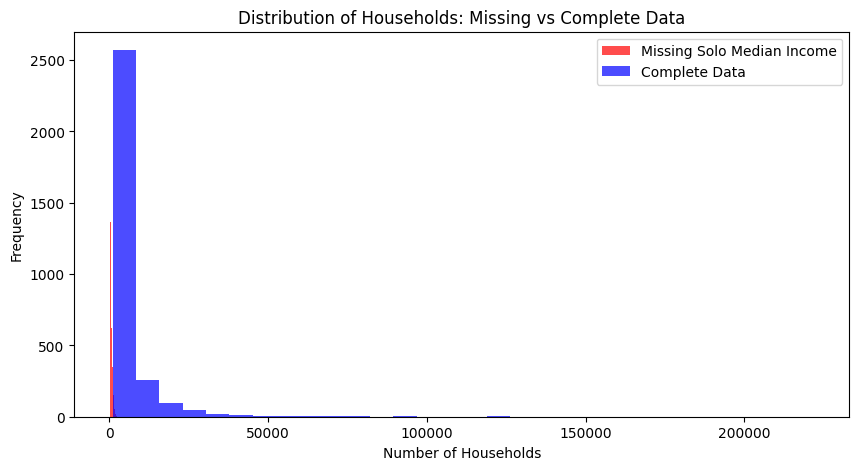

In [24]:
# 1. Create a subset of rows where detailed income is missing
df_missing_details = df_social_mobility_matrix[df_social_mobility_matrix['solo_median_income'].isna()]

# 2. Compare the average number of households between missing data and full data
mean_households_missing = df_missing_details['nb_households'].mean()
mean_households_full = df_social_mobility_matrix.dropna(subset=['solo_median_income'])['nb_households'].mean()

print(f"Average households in missing data: {mean_households_missing:.0f}")
print(f"Average households in complete data: {mean_households_full:.0f}")

# 3. Create a density plot to visualize the distribution
# This will show that missing values are concentrated in low-population areas
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(df_missing_details['nb_households'], bins=30, alpha=0.7, label='Missing Solo Median Income', color='red')
plt.hist(df_social_mobility_matrix.dropna(subset=['solo_median_income'])['nb_households'], bins=30, alpha=0.7, label='Complete Data', color='blue')
plt.xlabel('Number of Households')
plt.ylabel('Frequency')
plt.title('Distribution of Households: Missing vs Complete Data')
plt.legend()
plt.show()

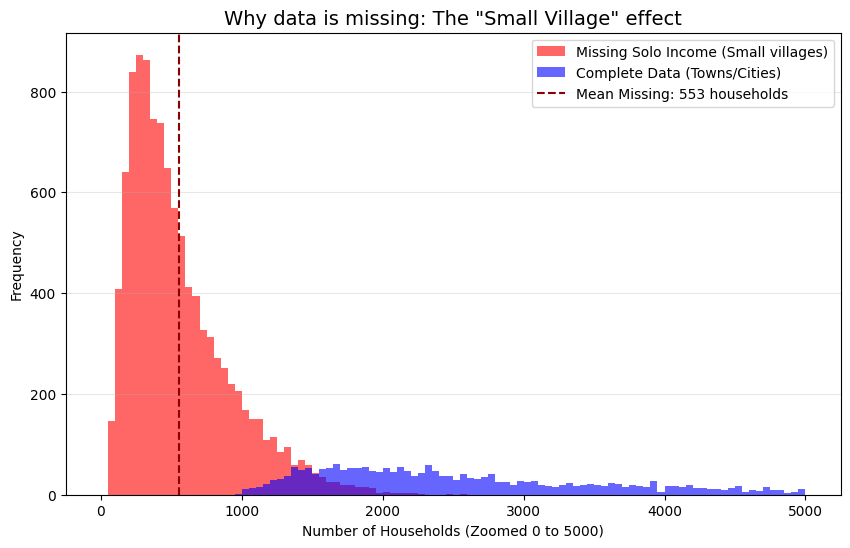

In [27]:
# 1. Define the two groups
# Group 1: Municipalities where detailed income is missing
df_missing_details = df_social_mobility_matrix[df_social_mobility_matrix['solo_median_income'].isna()]

# Group 2: Municipalities where data is complete (The ~13,700 remaining)
df_complete_data = df_social_mobility_matrix.dropna(subset=['solo_median_income'])

# 2. Plotting with a focus on small municipalities (Zoom)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Use a specific range to see the "cliff" where data starts appearing
plt.hist(df_missing_details['nb_households'], bins=100, range=(0, 5000), 
         color='red', alpha=0.6, label='Missing Solo Income (Small villages)')

plt.hist(df_complete_data['nb_households'], bins=100, range=(0, 5000), 
         color='blue', alpha=0.6, label='Complete Data (Towns/Cities)')

plt.axvline(x=mean_households_missing, color='darkred', linestyle='--', 
            label=f'Mean Missing: {mean_households_missing:.0f} households')

plt.title('Why data is missing: The "Small Village" effect', fontsize=14)
plt.xlabel('Number of Households (Zoomed 0 to 5000)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()